In [1]:
# This jupyter notebook uses the iris dataset for learning and practise follwoing typical ML algorithms
#      (1) Decision Tree with entropy measure
#      (2) As (1) but with PCA processed data, standarize => explained covariance => new data frame
#      (3) Using KMeans (unsupervised learning) to clustering the flower tpye
#      (4) Using KNN(K-Nearest-Neighbors)
#      (5) Using MeanShift (unsupervised learning)
#      (6) Build a MLP(Multi-Layer Perceptron) with 2 Dense layers 

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn import datasets
from sklearn.tree import DecisionTreeClassifier as DTs, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.cluster import MeanShift, estimate_bandwidth

In [3]:
# Load iris dataset
IrisData = datasets.load_iris()
print((IrisData.keys()),'\n')
print(IrisData.feature_names,'\n')
print(IrisData.target_names)

# Slpit data to train and test data
X = IrisData.data
Y = IrisData.target

IrisTrainData,IrisTestData, IrisTrainTarget, IrisTestTarget = train_test_split(X,Y,test_size=0.33, random_state=42)

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module']) 

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)'] 

['setosa' 'versicolor' 'virginica']


In [4]:
# Create decision tree model and train it
Clf = DTs(criterion='entropy', min_samples_leaf=5).fit(IrisTrainData, IrisTrainTarget)

[Text(0.4444444444444444, 0.9, 'petal length (cm) <= 2.45\nentropy = 1.583\nsamples = 100\nvalue = [31, 35, 34]\nclass = versicolor'),
 Text(0.3333333333333333, 0.7, 'entropy = 0.0\nsamples = 31\nvalue = [31, 0, 0]\nclass = setosa'),
 Text(0.38888888888888884, 0.8, 'True  '),
 Text(0.5555555555555556, 0.7, 'petal width (cm) <= 1.75\nentropy = 1.0\nsamples = 69\nvalue = [0, 35, 34]\nclass = versicolor'),
 Text(0.5, 0.8, '  False'),
 Text(0.3333333333333333, 0.5, 'petal length (cm) <= 4.95\nentropy = 0.485\nsamples = 38\nvalue = [0, 34, 4]\nclass = versicolor'),
 Text(0.2222222222222222, 0.3, 'sepal length (cm) <= 5.15\nentropy = 0.196\nsamples = 33\nvalue = [0, 32, 1]\nclass = versicolor'),
 Text(0.1111111111111111, 0.1, 'entropy = 0.722\nsamples = 5\nvalue = [0, 4, 1]\nclass = versicolor'),
 Text(0.3333333333333333, 0.1, 'entropy = 0.0\nsamples = 28\nvalue = [0, 28, 0]\nclass = versicolor'),
 Text(0.4444444444444444, 0.3, 'entropy = 0.971\nsamples = 5\nvalue = [0, 2, 3]\nclass = virgin

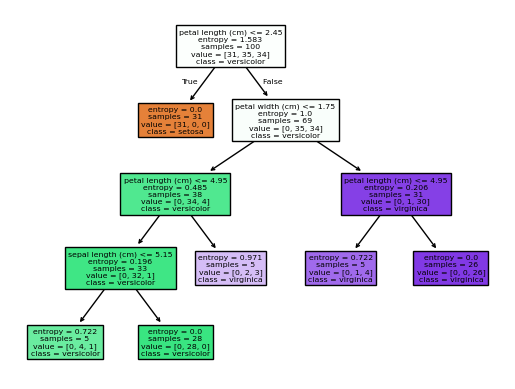

In [5]:
# Plot the tree
plot_tree(Clf,filled=True,feature_names = IrisData.feature_names, class_names = IrisData.target_names)

In [6]:
# Cacluate the prediction score
TrainScore = Clf.score(IrisTestData, IrisTestTarget)
TestScore = Clf.score(IrisTrainData, IrisTrainTarget)

print(f'Prediction Score with train data {TrainScore}')
print(f'Prediction Score with test data {TestScore}')


Prediction Score with train data 1.0
Prediction Score with test data 0.96


In [7]:
# Decisiontree method shows 100% accuracy with train data and 96% accuracy with test data

In [8]:
# Using PCA
# Create another new decision tree model and training it with data which are processed with PCA

# 1st Step for PCA procesing
# Standarize the data, mean = 0 and std = 1.
IrisStdData = StandardScaler().fit_transform(X)

# Excute PCA transfomr with origin number of features to get the explained covariance
IrisPCAMdl = PCA(n_components = 4)
IrisPCAData = IrisPCAMdl.fit_transform(IrisStdData)

print(IrisPCAMdl.explained_variance_ratio_)

[0.72962445 0.22850762 0.03668922 0.00517871]


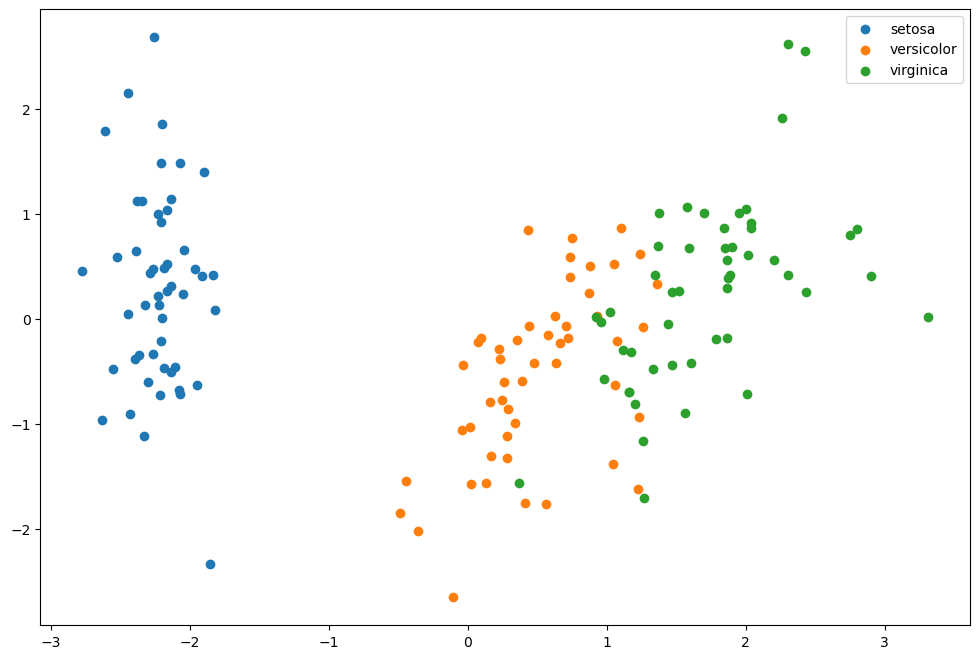

In [9]:
# The explained covariance shows, the summe of thw first 2 components have weight > 99%, so reduce the dimenstion to 2
IrisPCAData = PCA(n_components = 2).fit_transform(IrisStdData)

# Build panda data frame with PCA procssed iris data
PdIrisPCAData = pd.DataFrame(IrisPCAData,columns=['PCA1','PCA2'])
PdIrisPCAData['Label'] = Y

figure1 = plt.figure(figsize=(12,8))
plt.scatter(PdIrisPCAData['PCA1'][PdIrisPCAData['Label']==0],PdIrisPCAData['PCA2'][PdIrisPCAData['Label']==0],label='setosa')
plt.scatter(PdIrisPCAData['PCA1'][PdIrisPCAData['Label']==1],PdIrisPCAData['PCA2'][PdIrisPCAData['Label']==1],label='versicolor')
plt.scatter(PdIrisPCAData['PCA1'][PdIrisPCAData['Label']==2],PdIrisPCAData['PCA2'][PdIrisPCAData['Label']==2],label='virginica')
plt.legend()

Prediction Score with train data 0.92
Prediction Score with test data 0.93


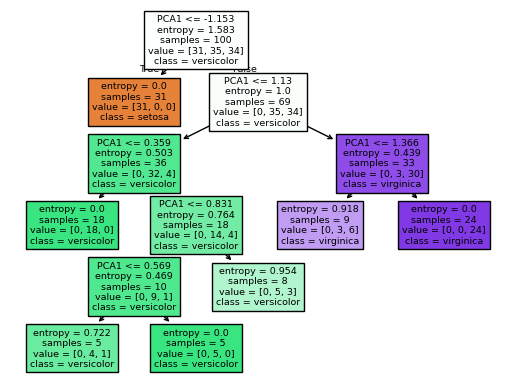

In [10]:
#Split new data for train new decision tree model
IrisTrainData,IrisTestData, IrisTrainTarget, IrisTestTarget = train_test_split(IrisPCAData,Y,test_size=0.33, random_state=42)

# Create decision tree model and train it
Clf = DTs(criterion='entropy', min_samples_leaf=5).fit(IrisTrainData, IrisTrainTarget)

# Plot the tree
plot_tree(Clf,filled=True,feature_names = ['PCA1','PCA2'], class_names = IrisData.target_names)

# cacluate the prediction score
TrainScore = Clf.score(IrisTestData, IrisTestTarget)
TestScore = Clf.score(IrisTrainData, IrisTrainTarget)

print(f'Prediction Score with train data {TrainScore}')
print(f'Prediction Score with test data {TestScore}')

In [11]:
# The accuracy of the train with PCA processed data is little bit lower than with original data

In [12]:
# KMeans 
# An unsupervised learning, but we have to know the target number of cluste

# Build KMeans model and train 
# Due to unsupervised learning it doesn't make sense to split the data to train and test data
KM = KMeans(n_clusters = 3, random_state=1).fit(X)
central = KM.cluster_centers_
PredLabel = KM.predict(X)

ClusterLabel, ClusterMembers = np.unique(PredLabel, return_counts=True)
print(ClusterLabel,ClusterMembers)
# [0 1 2] [61 50 39]

TargetCluster, TargeeSamples= np.unique(Y, return_counts=True)
print(TargetCluster,TargeeSamples)
# [0 1 2] [50 50 50]


[0 1 2] [61 50 39]
[0 1 2] [50 50 50]


In [13]:
# All three flower types have the same number of samples.
# Unable to check the predict cluster label with orignal
# The results above [61 50 39] predicted vs. [50 50 50] expected show clearly the prediction accuray are not very good 

In [14]:
# KNN (K-Nearest-Neighbors) supervised learning

# Split data for train and test
IrisTrainData,IrisTestData, IrisTrainTarget, IrisTestTarget = train_test_split(X,Y,test_size=0.33, random_state=42)

# Build KNN model and train
KNN = KNeighborsClassifier(n_neighbors=3).fit(IrisTrainData,IrisTrainTarget)

# Prediction with train data
PredTrainTarget = KNN.predict(IrisTrainData)
TrainAccuracy = accuracy_score(PredTrainTarget,IrisTrainTarget)
print(TrainAccuracy)

PredTestTarget = KNN.predict(IrisTestData)
TestAccuracy = accuracy_score(PredTestTarget,IrisTestTarget)
print(TestAccuracy)

0.96
0.98


In [15]:
# KNN performance in this case is not bad

In [16]:
# MeanShift
# An unsupervised learning, but we are not able to specify the target number of cluste

# Calculate the band width 
BandWidth = estimate_bandwidth(X)
# Buikd MeansShift model and train
MS = MeanShift(bandwidth=BandWidth).fit(X)

PredLabel = MS.predict(X)

ClusterLabel, ClusterMembers = np.unique(PredLabel, return_counts=True)
print(ClusterLabel,ClusterMembers)

TargetCluster, TargeeSamples = np.unique(Y, return_counts=True)
print(TargetCluster,TargeeSamples)

[0 1] [99 51]
[0 1 2] [50 50 50]


In [17]:
# Obviously the MeanShift method is unsuitable for the task, only 2 clusters are defined.
# Based on the plot with PCA1 and PCA2 it is also comprehensible the versicolor and virginica are very close to each other 

In [18]:
# Module needed for building MLP(Multi-Layer Perceptron)

from keras.models import Sequential
from keras.layers import Input, Dense
from keras.utils import plot_model
from keras.utils import to_categorical
from keras.callbacks import EarlyStopping

In [19]:
# Create the MLP model
MLPMdl = Sequential()

# Define the input shape 
MLPMdl.add(Input(shape=(4,)))  # 4 because of number of features

# Add Dense layer
MLPMdl.add(Dense(units=8,activation='relu'))
MLPMdl.add(Dense(units=3,activation='softmax')) #softmax instead of sigmoid due to multi-class classification

MLPMdl.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

MLPMdl.summary()

#plot_model(MLPMdl, to_file='MLPMdl.png', show_shapes=True)

# Define callback function for early stopping the training, to avoid overfiting
BreakTrain = EarlyStopping(
    monitor = 'val_loss',     
    patience = 5,             # wait 5 epoch without improvment    
    restore_best_weights = True,  # take the best weight result back
    start_from_epoch = 400 #epochs to wait before starting to monitor improvement
)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 67 (268.00 B)

 Trainable params: 67 (268.00 B)

 Non-trainable params: 0 (0.00 B)

In [20]:
# Conver label one dimension to the one hot array

OneHotY = to_categorical(Y, num_classes=3)

IrisTrainData,IrisTestData, IrisTrainTarget, IrisTestTarget = train_test_split(X,OneHotY,test_size=0.33, random_state=42)

In [26]:
# Train with early stop
#MLPMdl.fit(IrisTrainData,IrisTrainTarget,batch_size=12, initial_epoch = 0, validation_split = 0.9, epochs=100, callbacks=[BreakTrain], verbose=0)

# Train without early stop
MLPMdl.fit(IrisTrainData,IrisTrainTarget,batch_size=12, initial_epoch = 0, epochs=100, verbose=0)


In [27]:
def Convert2OneHot(SoftMaxResults):
    PredictClass = np.argmax(SoftMaxResults, axis=1)
    OneHot = np.zeros_like(SoftMaxResults)
    OneHot[np.arange(len(SoftMaxResults)), PredictClass] = 1
    return OneHot

In [28]:
IrisPredTrainData = MLPMdl.predict(IrisTrainData)

IrisPredTrainData = Convert2OneHot(IrisPredTrainData)

Accuracy = accuracy_score(IrisPredTrainData,IrisTrainTarget)
print(Accuracy)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 773us/step
0.99


In [29]:
IrisPredTestData = MLPMdl.predict(IrisTestData)

IrisPredTestData = Convert2OneHot(IrisPredTestData)

Accuracy = accuracy_score(IrisPredTestData,IrisTestTarget)
print(Accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
0.96


In [25]:
# creat for loop to check how the accuracy is dependent from number of epochs
n = range(1,20)
for i in n:
    # Train Model
    MLPMdl.fit(IrisTrainData,IrisTrainTarget,batch_size=12,epochs=100, verbose=0)
    # Predict train data
    IrisPredTrainData = MLPMdl.predict(IrisTrainData)
    IrisPredTrainData = Convert2OneHot(IrisPredTrainData)
    # Calculate the accuracy
    AccuracyOfTrainData = accuracy_score(IrisPredTrainData,IrisTrainTarget)
    # Predict test data
    IrisPredTestData = MLPMdl.predict(IrisTestData)
    IrisPredTestData = Convert2OneHot(IrisPredTestData)
    # Calculate the accuracy
    AccuracyOfTestData = accuracy_score(IrisPredTestData,IrisTestTarget)
    print(f'epoachs = {i*100}, Train Accuracy = {AccuracyOfTrainData} Test Accuracy = {AccuracyOfTestData} \n\n')
    
    


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 491us/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 861us/step
epoachs = 100, Train Accuracy = 0.98 Test Accuracy = 0.98 


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 481us/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 968us/step
epoachs = 200, Train Accuracy = 0.98 Test Accuracy = 0.96 


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 691us/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
epoachs = 300, Train Accuracy = 0.98 Test Accuracy = 0.96 


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 638us/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
epoachs = 400, Train Accuracy = 0.98 Test Accuracy = 0.96 


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 563us/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
epoachs = 500, Train Accuracy = 0.98 Test Accuracy = 0.96 


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 505us/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
epoachs = 600, Train Accuracy = 0.98 Test Accuracy = 0.96 


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 557us/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  
epoachs = 700, Train Accuracy = 0.98 Test Accuracy = 0.96 


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5